# Load Python Packages

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

# Load Dataset and Check Initial Records

In [21]:
df = pd.read_csv('/content/drive/MyDrive/fraud_data.csv')
print("Original Dataset shape:", df.shape)
df.head()

Original Dataset shape: (21693, 30)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,1.176563,0.323798,0.536927,1.047002,-0.368652,-0.728586,0.084678,-0.069246,-0.266389,0.155315,...,-0.109627,-0.341365,0.057845,0.499180,0.415211,-0.581949,0.015472,0.018065,4.67,0
1,0.681109,-3.934776,-3.801827,-1.147468,-0.735540,-0.501097,1.038865,-0.626979,-2.274423,1.527782,...,0.652202,0.272684,-0.982151,0.165900,0.360251,0.195321,-0.256273,0.056501,912.00,0
2,1.140729,0.453484,0.247010,2.383132,0.343287,0.432804,0.093380,0.173310,-0.808999,0.775436,...,-0.003802,0.058556,-0.121177,-0.304215,0.645893,0.122600,-0.012115,-0.005945,1.00,0
3,-1.107073,-3.298902,-0.184092,-1.795744,2.137564,-1.684992,-2.015606,-0.007181,-0.165760,0.869659,...,0.130648,0.329445,0.927656,-0.049560,-1.892866,-0.575431,0.266573,0.414184,62.10,0
4,-0.314818,0.866839,-0.124577,-0.627638,2.651762,3.428128,0.194637,0.670674,-0.442658,0.133499,...,-0.312774,-0.799494,-0.064488,0.953062,-0.429550,0.158225,0.076943,-0.015051,2.67,0


# Check Missing Values in Dataset

In [22]:
df.isnull().sum()


,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


# Separate Features and Target Variable

In [23]:
X = df.drop('Class', axis=1)  # all columns except target
y = df['Class']               # target column


# Split Dataset into Training and Testing Sets &  Apply SMOTE to Balance Training Data

In [24]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# First split original data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE only on training data
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("After SMOTE:\n", y_train_res.value_counts())


Before SMOTE:
 Class
0    17069
1      285
Name: count, dtype: int64
After SMOTE:
 Class
0    17069
1    17069
Name: count, dtype: int64


# Apply Feature Scaling Using StandardScaler & Prepare DataFrames for Processed Data

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scale after SMOTE
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

X_train_df = pd.DataFrame(X_train_res, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)


# Initialize Machine Learning Models for Training & Configure Class Imbalance Handling Parameters

In [26]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    ),

    "XGBoost": xgb.XGBClassifier(
        eval_metric='logloss',
        random_state=42,
        scale_pos_weight = (y_train.value_counts()[0] / y_train.value_counts()[1])
    ),

    "LightGBM": lgb.LGBMClassifier(
        random_state=42,
        class_weight='balanced',
        verbose=-1
    )
}

# Train Models and Evaluate Performance Metrics

In [14]:
from sklearn.metrics import classification_report, f1_score, roc_auc_score, confusion_matrix, accuracy_score, precision_score, recall_score

results = []
conf_matrices = {}

for name, model in models.items():
    print(f"\n===== {name} =====")

    # Train and Predict
    if name in ["Random Forest", "XGBoost", "LightGBM"]:
        model.fit(X_train_res, y_train_res)   # no scaling needed
        y_pred = model.predict(X_test_df)
        y_prob = model.predict_proba(X_test_df)[:,1]
    else:
        model.fit(X_train_scaled, y_train_res)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:,1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)
    fn = cm[1][0] # False Negatives

    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"AUC: {auc:.4f}")
    print("False Negatives:", fn)

    results.append([name, acc, prec, rec, f1, auc, fn])
    conf_matrices[name] = cm



===== Logistic Regression =====
              precision    recall  f1-score   support

           0       1.00      0.97      0.99      4268
           1       0.38      0.97      0.54        71

    accuracy                           0.97      4339
   macro avg       0.69      0.97      0.76      4339
weighted avg       0.99      0.97      0.98      4339

Accuracy: 0.9733
Precision: 0.3770
Recall: 0.9718
F1: 0.5433
AUC: 0.9926
False Negatives: 2

===== Random Forest =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4268
           1       0.93      0.90      0.91        71

    accuracy                           1.00      4339
   macro avg       0.96      0.95      0.96      4339
weighted avg       1.00      1.00      1.00      4339

Accuracy: 0.9972
Precision: 0.9275
Recall: 0.9014
F1: 0.9143
AUC: 0.9893
False Negatives: 7

===== XGBoost =====
              precision    recall  f1-score   support

           0       1.00   

# Compare Model Performance Using Evaluation Metrics

In [15]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC", "False Negatives"])
results_df = results_df.sort_values(by="AUC-ROC", ascending=False)

print("Model Performance Comparison:")
display(results_df)


Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC,False Negatives
0,Logistic Regression,0.973266,0.377049,0.971831,0.543307,0.992621,2
3,LightGBM,0.996082,0.864865,0.901408,0.882759,0.991898,7
1,Random Forest,0.997234,0.927536,0.901408,0.914286,0.989283,7
2,XGBoost,0.994699,0.779070,0.943662,0.853503,0.981810,4


# Visualize Model Comparison Across Performance Metrics

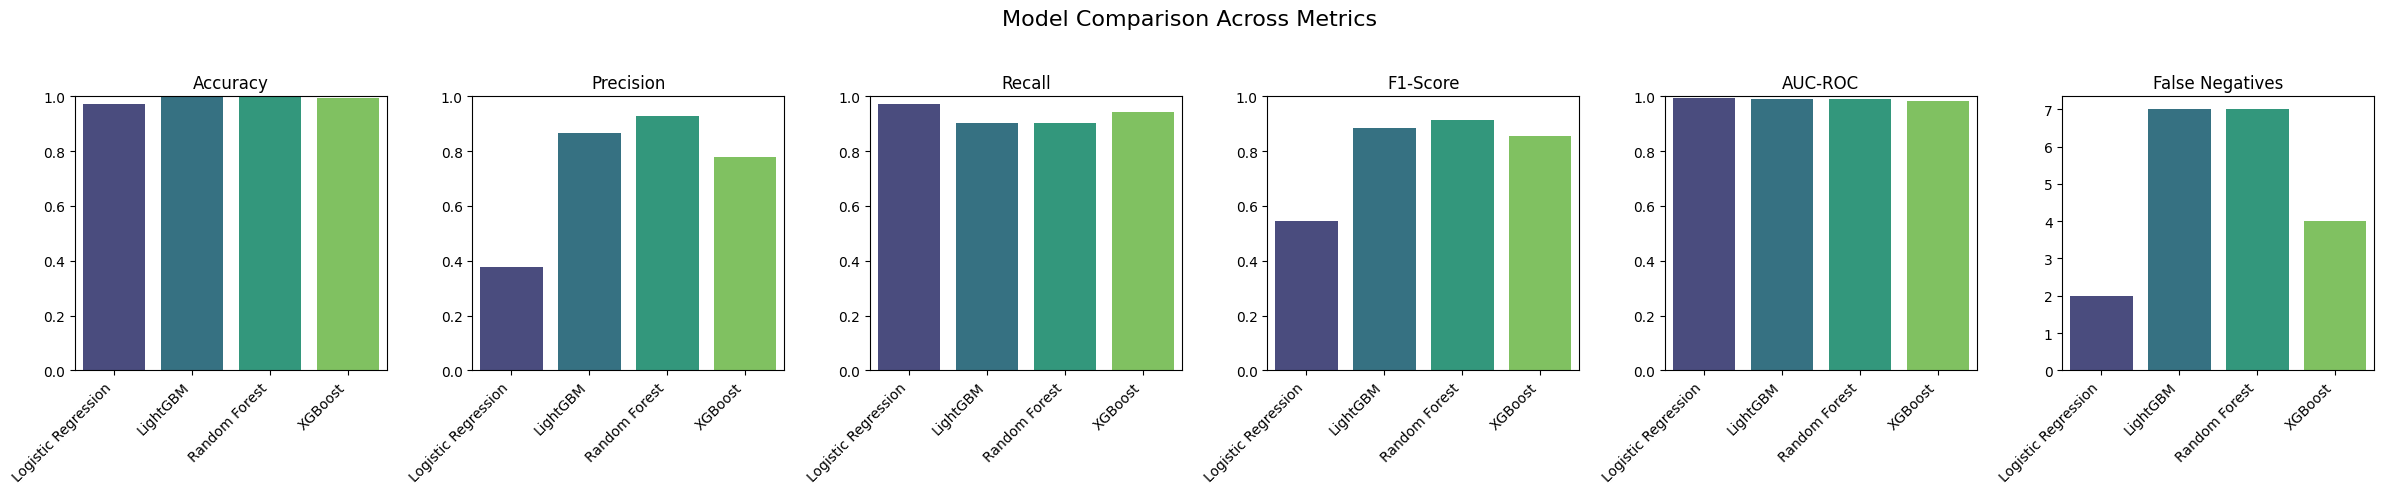

In [16]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC", "False Negatives"]
num_metrics = len(metrics_to_plot)

plt.figure(figsize=(num_metrics * 4, 5)) # Adjust figure size dynamically

for i, metric in enumerate(metrics_to_plot, 1):
    plt.subplot(1, num_metrics, i)
    sns.barplot(x=results_df["Model"], y=results_df[metric], palette='viridis', hue=results_df["Model"], legend=False)
    plt.title(metric)
    # Only set y-limit for metrics that are percentages/ratios
    if metric not in ["False Negatives"]:
        plt.ylim(0, 1)
    plt.xlabel('')
    plt.ylabel('')
    plt.xticks(rotation=45, ha='right')

plt.suptitle('Model Comparison Across Metrics', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# Display Confusion Matrices for All Trained Models

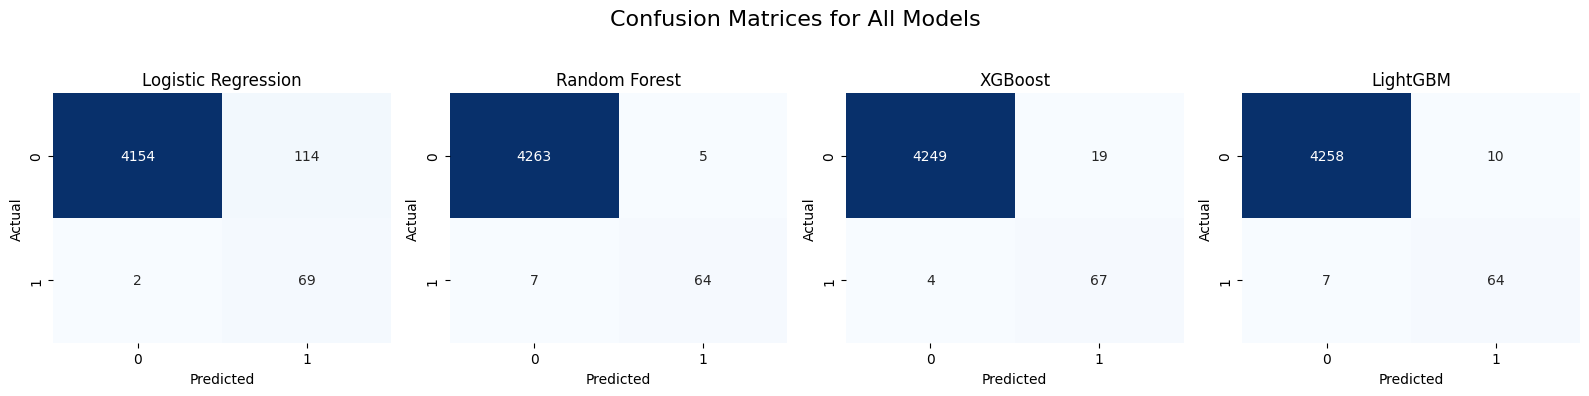

In [17]:
model_names = list(conf_matrices.keys())
num_models = len(model_names)

plt.figure(figsize=(16,4))  # Adjust width/height as needed

for i, name in enumerate(model_names, 1):
    plt.subplot(1, num_models, i)
    sns.heatmap(conf_matrices[name], annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(name)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

plt.suptitle('Confusion Matrices for All Models', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# Plot ROC Curve Comparison for All Models

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


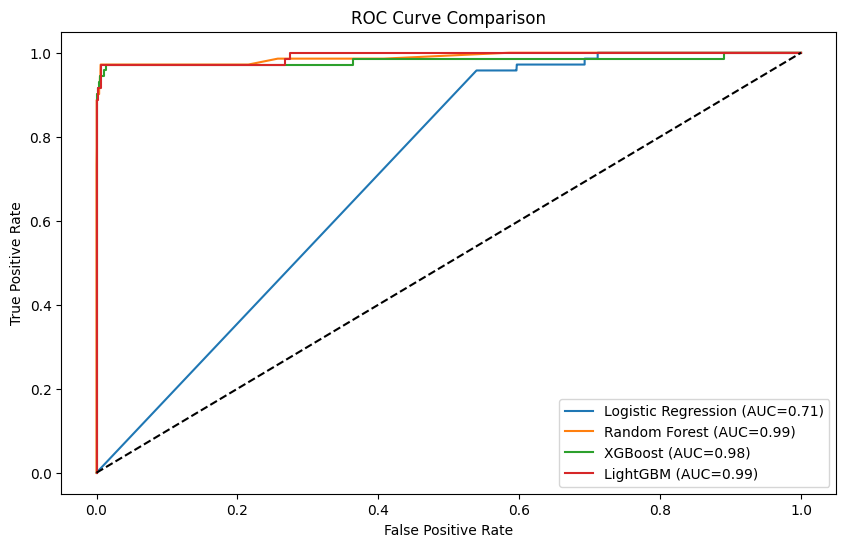

In [18]:
plt.figure(figsize=(10,6))
for name, model in models.items():
    if name == "LightGBM":
        y_prob = model.predict_proba(X_test_df)[:, 1]
    else:
        y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, y_prob):.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

# Visualize Feature Importance Using Random Forest Model

/tmp/ipykernel_15309/1850716771.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importance.values, y=feat_importance.index, palette='viridis')


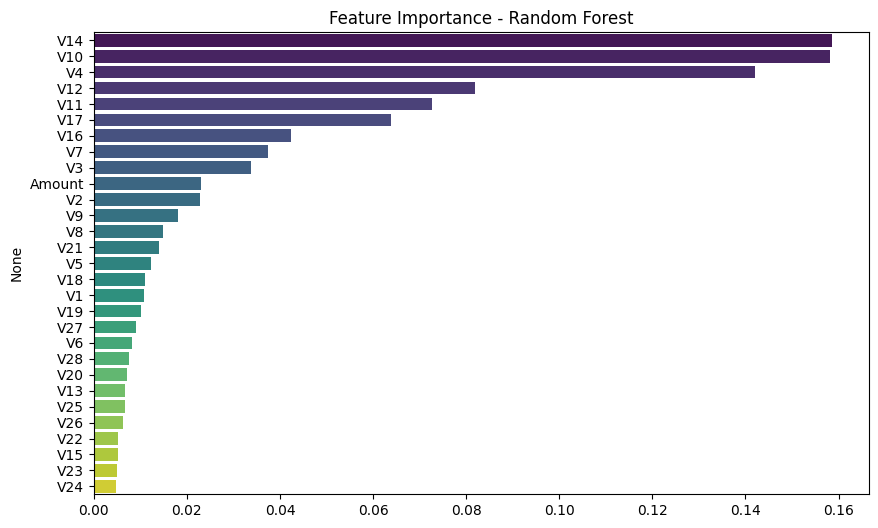

In [19]:
# Example: Feature Importance for Random Forest
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
feat_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_importance.values, y=feat_importance.index, palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.show()
